# 1. 目标分割的掩码使用

In [ ]:
from ultralytics import YOLO

# 加载图像处理模式
model = YOLO("./pts/yolo11n-seg.pt")  # load an official model

# 分割目标
results = model("./imgs/me.jpg")  # predict on an image

print(results)




image 1/1 E:\01AI\25\imgs\me.jpg: 640x480 1 person, 3 traffic lights, 1 cell phone, 61.9ms
Speed: 2.2ms preprocess, 61.9ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 480)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork'

In [2]:
results[0].show()  # Display results

In [3]:
result = results[0]
print("分割的目标个数：", len(result.masks.xy))
print(result.masks.data.shape)

分割的目标个数： 5
torch.Size([5, 640, 480])


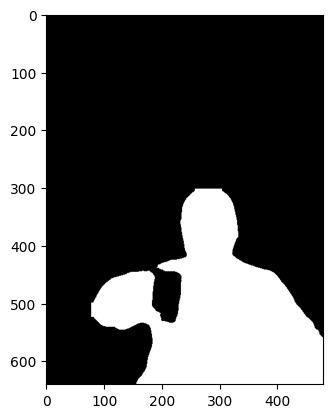

In [4]:
import matplotlib.pyplot as plt

plt.imshow(result.masks.data.cpu()[0].numpy(), cmap="gray")

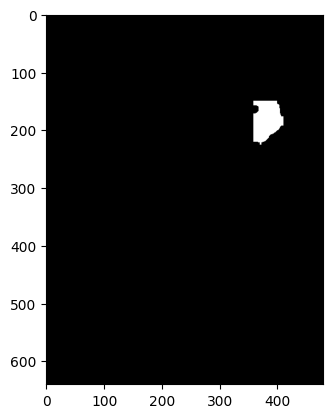

In [5]:
plt.imshow(result.masks.data.cpu()[1].numpy(), cmap="gray")

In [6]:
result.masks.data.cpu().numpy()[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], shape=(640, 480), dtype=uint8)

(640, 480)


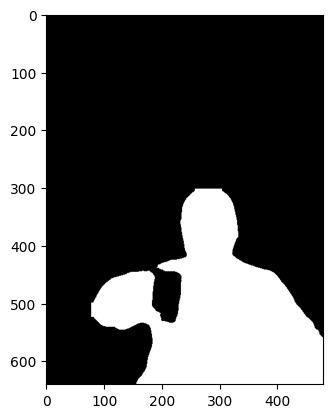

In [7]:
obj1 = result.masks.data.cpu().numpy()[0]* 255
plt.imshow(obj1, cmap="gray")
print(obj1.shape)

(4096, 3072, 3)


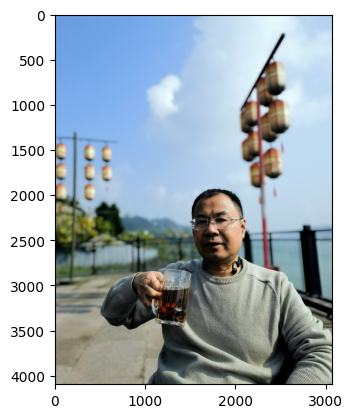

In [8]:
import cv2
img = cv2.imread("./imgs/me.jpg", cv2.IMREAD_COLOR_RGB)
print(img.shape)
plt.imshow(img)

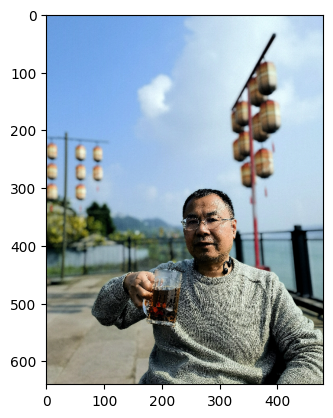

In [9]:
h, w = obj1.shape
img = cv2.resize(img, (w, h))
plt.imshow(img, cmap="gray")

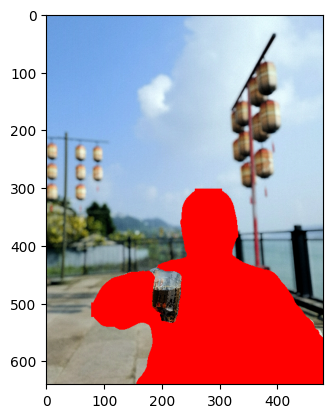

In [10]:
contours, _ = cv2.findContours(obj1, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
cv2.drawContours(img, contours, 0, (255, 0, 0), -1)
plt.imshow(img)

------

# 利用位运算进行图像操作


image 1/1 E:\01AI\25\imgs\me.jpg: 640x480 1 person, 3 traffic lights, 1 cell phone, 35.1ms
Speed: 3.5ms preprocess, 35.1ms inference, 7.0ms postprocess per image at shape (1, 3, 640, 480)


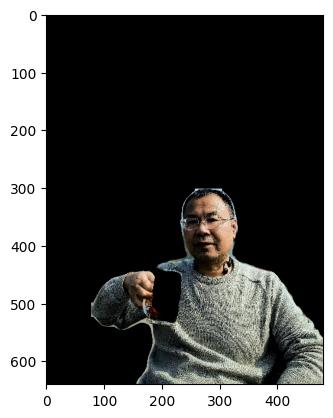

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


# 加载图像处理模式
model = YOLO("./pts/yolo11n-seg.pt")  # load an official model
# 分割目标
results = model("./imgs/me.jpg")  # predict on an image

img = cv2.imread("./imgs/me.jpg", cv2.IMREAD_COLOR_RGB)

obj1 = result.masks.data.cpu().numpy()[0]* 255
h, w = obj1.shape

obj1 = np.stack([obj1, obj1, obj1], axis=2)


img = cv2.resize(img, (w, h))

img_new  = img & obj1

plt.imshow(img_new)

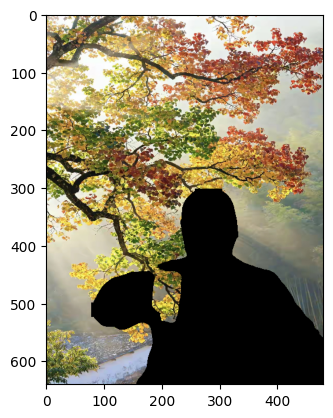

In [18]:
jing = cv2.imread("./imgs/jing.jpg", cv2.IMREAD_COLOR_RGB)
jing = cv2.resize(jing, (w, h))

obj1_invert = 255 - obj1

jing_new  = jing & obj1_invert
plt.imshow(jing_new)

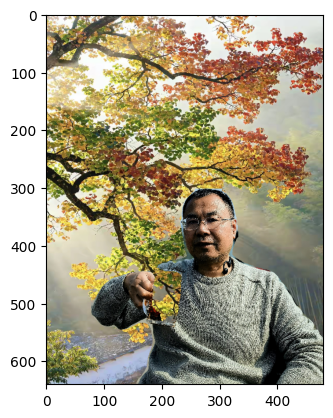

In [20]:
re = img_new + jing_new
plt.imshow(re)

# 利用numpy的下标运算进行图像操作

# 利用numpy的掩码合并图像